In [17]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os
import control as ctl

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [18]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read()).get('target')
OPTIONS

{'test': 5, 'axis': 'x'}

In [19]:
PATH = f'../files/test{OPTIONS['test']}/rolling_{OPTIONS['axis']}'
print(PATH)
print(os.listdir(PATH))

../files/test5/rolling_x
['reference', 'info.json', 'target']


In [20]:
TARGET_VAR = 'roll'
LIMITS     = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(DYNAMIC_LIMITS)
print(STATIC_LIMITS)

{'dynamic': [5, 120], 'static': [150, 999999999]}
[5, 120]
[150, 999999999]


# IMPORTANDO DADOS

In [21]:
df = pd.read_csv(f'{PATH}/target/data.csv')
df

,yaw,time,wz,wy,tmp,e,roll,wx,ay,pitch,ax,az
0,5357,9.536743e-07,14266,33475,50.4,0.252,-3352,13780,-10023,-549,63733,994305
1,5358,4.137588e-02,12575,-16000,50.4,0.252,-3351,-5714,-11401,-554,57729,996413
2,5360,1.444066e-01,-26685,8149,50.5,0.252,-3351,28592,-9008,-548,60456,995570
3,5367,2.432790e-01,-12321,-47587,50.4,0.252,-3355,3167,-9803,-535,58257,995535
4,5601,3.413076e-01,12601,1958507,50.5,-3.492,-1293,-441711,-117008,-1134,-337827,1025732
...,...,...,...,...,...,...,...,...,...,...,...,...
3093,7649,3.092585e+02,-6138,-29984,54.5,0.396,-3359,25000,-9454,-579,61179,996303
3094,7649,3.093545e+02,34457,-17035,54.2,0.396,-3359,37820,-13263,-577,58275,995953
3095,7651,3.094505e+02,-31484,-30838,54.5,0.396,-3359,-6058,-11356,-579,59679,995774
3096,7651,3.095561e+02,989,32828,54.5,0.396,-3359,17020,-10417,-578,58126,996764


- Convertendo pra radianos

In [22]:
def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df


df = convertAxis(df)
df.head()

,yaw,time,wz,wy,tmp,e,roll,wx,ay,pitch,ax,az
0,5.357,9.536743e-07,0.14266,0.33475,50.4,0.252,-3.352,0.13780,-0.098292,-0.549,0.625007,9.750801
1,5.358,4.137588e-02,0.12575,-0.16000,50.4,0.252,-3.351,-0.05714,-0.111806,-0.554,0.566128,9.771474
2,5.360,1.444066e-01,-0.26685,0.08149,50.5,0.252,-3.351,0.28592,-0.088338,-0.548,0.592871,9.763207
3,5.367,2.432790e-01,-0.12321,-0.47587,50.4,0.252,-3.355,0.03167,-0.096135,-0.535,0.571306,9.762863
4,5.601,3.413076e-01,0.12601,19.58507,50.5,-3.492,-1.293,-4.41711,-1.147457,-1.134,-3.312951,10.058995


- Formatando as colunas pra ficar igual a de referência

In [23]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,yaw,time,wz,wy,tmp,e,roll,wx,ay,pitch,ax,az
0,5.357,9.536743e-07,0.33475,-0.14266,50.4,0.252,-0.549,0.13780,9.750801,3.352,0.625007,-0.098292
1,5.358,4.137588e-02,-0.16000,-0.12575,50.4,0.252,-0.554,-0.05714,9.771474,3.351,0.566128,-0.111806
2,5.360,1.444066e-01,0.08149,0.26685,50.5,0.252,-0.548,0.28592,9.763207,3.351,0.592871,-0.088338
3,5.367,2.432790e-01,-0.47587,0.12321,50.4,0.252,-0.535,0.03167,9.762863,3.355,0.571306,-0.096135
4,5.601,3.413076e-01,19.58507,-0.12601,50.5,-3.492,-1.134,-4.41711,10.058995,1.293,-3.312951,-1.147457


In [24]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,yaw,time,wz,wy,tmp,e,roll,wx,ay,pitch,ax,az


# VISUALIZAÇÃO DE VARIÁVEIS

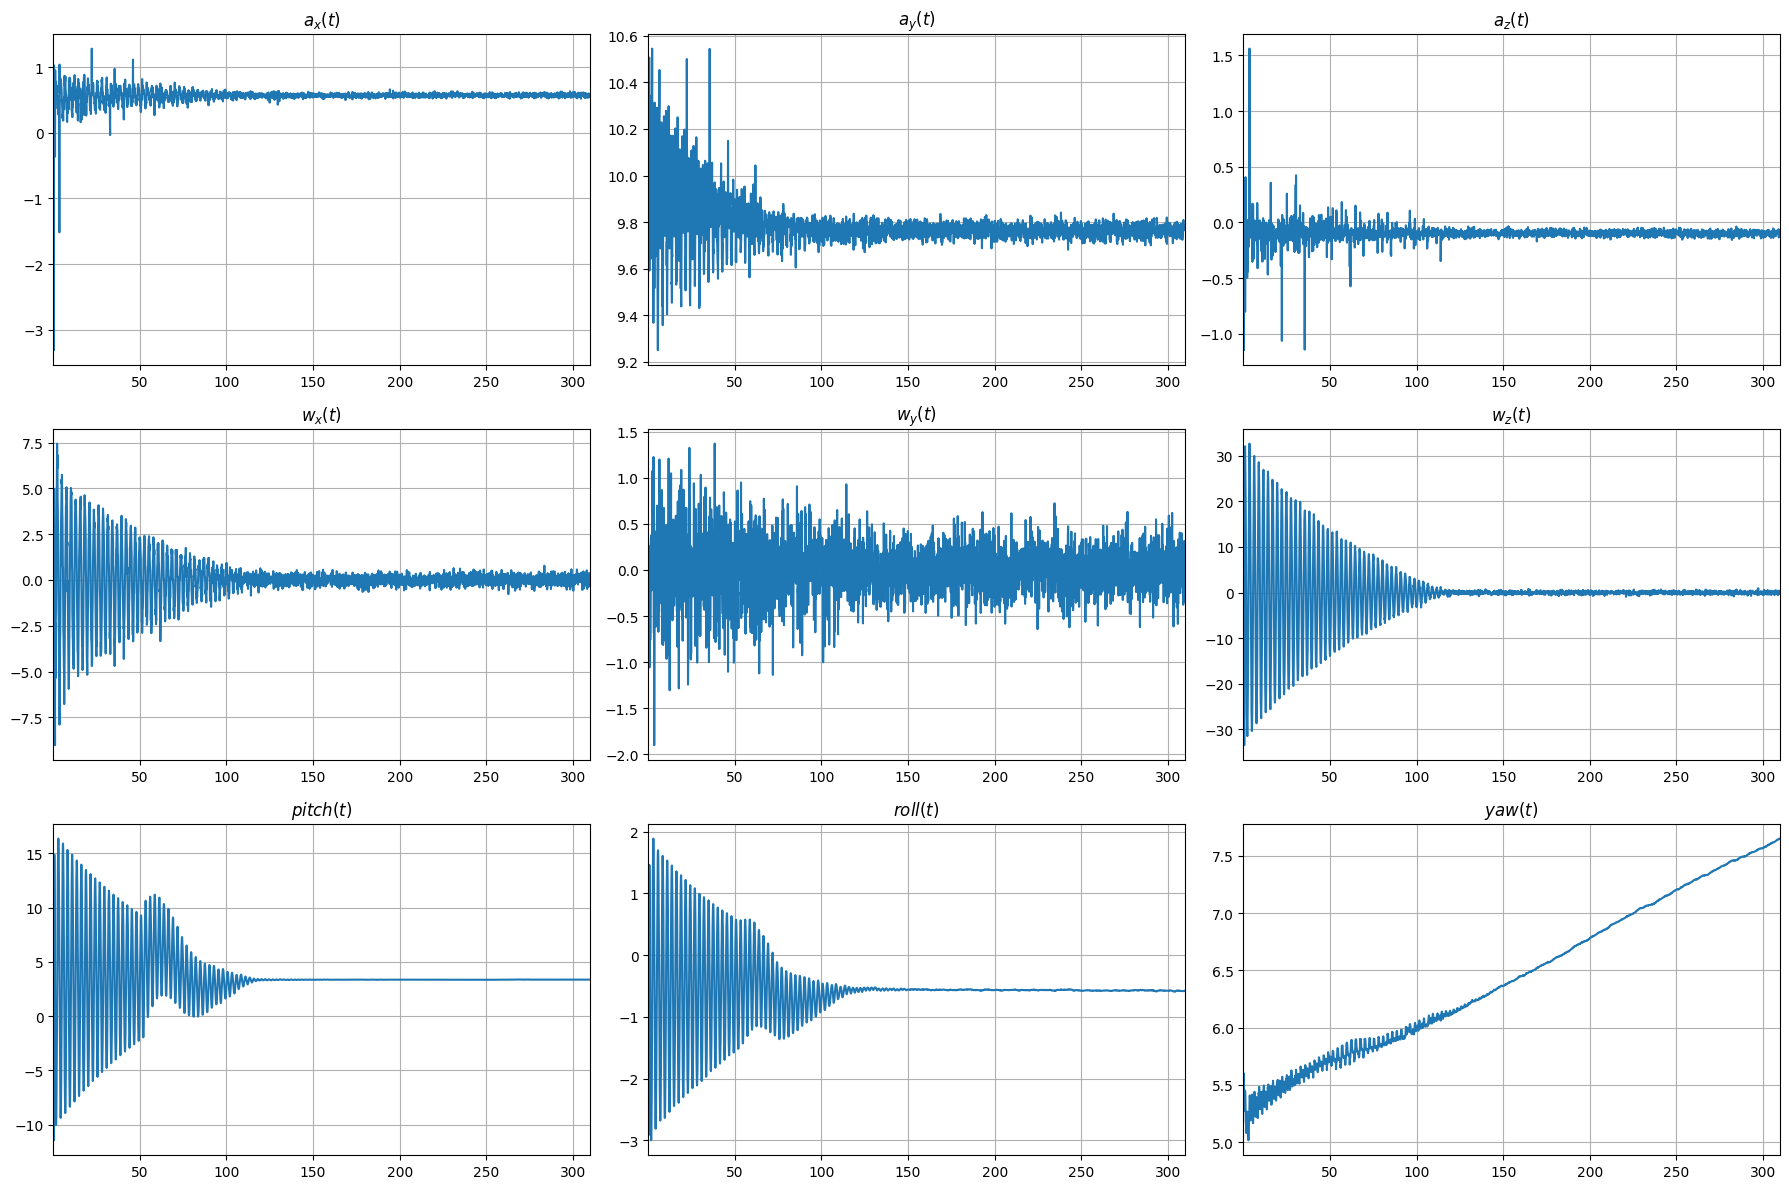

In [25]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = (t_max - t_min)
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

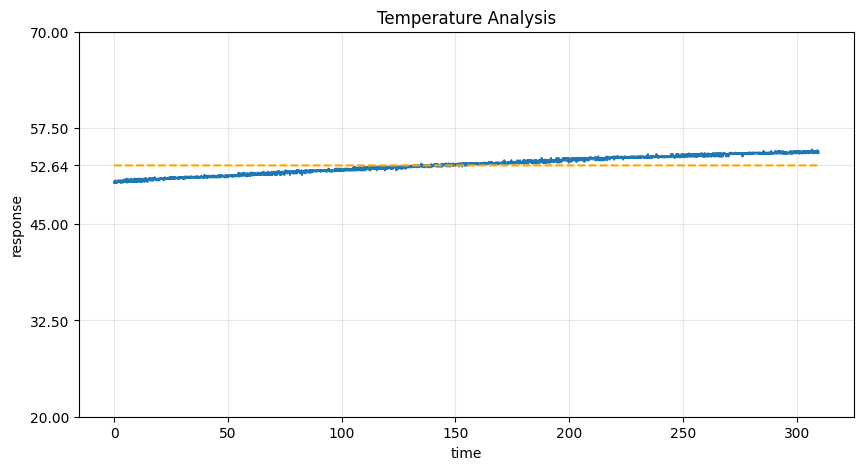

In [26]:
time = df.time.values
temp = df.tmp.values[:-100].mean()

plt.figure(figsize=(10, 5))
plt.plot(time, df.tmp)
plt.plot(time, temp*np.ones_like(time), '--', color='orange')
plt.grid(alpha=0.3); plt.xlabel('time'); plt.ylabel('response')
plt.yticks(list(np.linspace(20, 70, 5)) + [temp])
plt.title('Temperature Analysis')
plt.show()

# AMOSTRAGEM

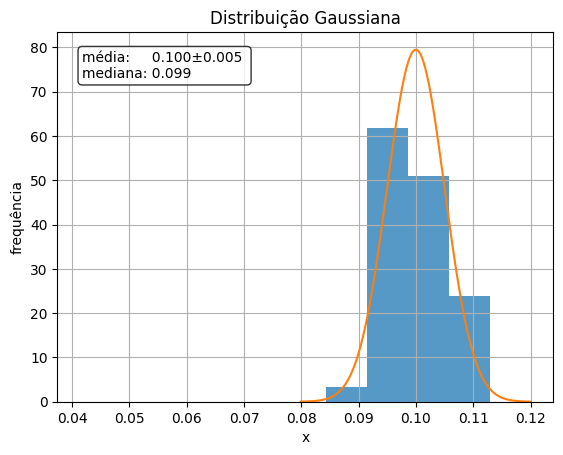

,time,yaw,wz,wy,tmp,e,roll,wx,ay,pitch,ax,az
0,0.0,5.357,0.33475,-0.14266,50.4,0.252,-0.549,0.13780,9.750801,3.352,0.625007,-0.098292
1,0.1,5.358,-0.16000,-0.12575,50.4,0.252,-0.554,-0.05714,9.771474,3.351,0.566128,-0.111806
2,0.2,5.360,0.08149,0.26685,50.5,0.252,-0.548,0.28592,9.763207,3.351,0.592871,-0.088338
3,0.3,5.367,-0.47587,0.12321,50.4,0.252,-0.535,0.03167,9.762863,3.355,0.571306,-0.096135
4,0.4,5.601,19.58507,-0.12601,50.5,-3.492,-1.134,-4.41711,10.058995,1.293,-3.312951,-1.147457
...,...,...,...,...,...,...,...,...,...,...,...,...
3093,309.3,7.649,-0.29984,0.06138,54.5,0.396,-0.579,0.25000,9.770395,3.359,0.599961,-0.092712
3094,309.4,7.649,-0.17035,-0.34457,54.2,0.396,-0.577,0.37820,9.766962,3.359,0.571483,-0.130066
3095,309.5,7.651,-0.30838,0.31484,54.5,0.396,-0.579,-0.06058,9.765207,3.359,0.585251,-0.111364
3096,309.6,7.651,0.32828,-0.00989,54.5,0.396,-0.578,0.17020,9.774916,3.359,0.570021,-0.102156


In [27]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
df

# FILTRAGEM

In [28]:
class FrequencyAnalyzer:
    def __init__(self, xData, yData):
        self.xData = np.asarray(xData)
        self.yData = np.asarray(yData)
        
        self.dt = np.mean(np.diff(self.xData))
        self.nSamples = len(self.yData)
        
        self.yFreq = None
        self.yMag  = None

    def update(self):
        fftResult  = np.fft.fft(self.yData)
        freqs      = np.fft.fftfreq(self.nSamples, self.dt)
        self.yFreq = np.fft.fftshift(freqs)
        self.yMag  = np.fft.fftshift(np.abs(fftResult)) / self.nSamples

    def plot(self, xLim=None, yLim=None, Fc=None):
        self.update()

        plt.plot(self.yFreq, self.yMag, label='blue', color='red', alpha=0.5)

        if Fc is not None:
            yMagRestricted = self.yMag.copy()
            allowed = (np.abs(self.yFreq) <= Fc)
            yMagRestricted[~allowed] = 0
            plt.plot(self.yFreq, yMagRestricted, label=f'Fc={Fc}', color='blue')
        
        plt.xlabel('frequency')
        plt.ylabel('amplitude')
        plt.grid(alpha=0.3)
        
        if xLim: plt.xlim(xLim)
        if yLim: plt.ylim(yLim)
        plt.legend()


class LowPassFilter:
    def __init__(self, Fc, dt):
        self.dt = dt
        self.Fc = Fc
        
        Wc = (2 * np.pi * Fc) 
        s  = ctl.TransferFunction.s
        
        H   = Wc / (s + Wc)
        H_z = ctl.c2d(H, dt, method='tustin')
        
        self.num, self.den = self.getFraction(H_z)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))

    def getFraction(self, G_z):
        num, den = ctl.tfdata(G_z)
        num = np.squeeze(num)
        den = np.squeeze(den)

        num = num / den[0]
        den = den / den[0]
        return num.tolist(), den.tolist()

    def compute(self):
        out = 0.0
        for i in range(len(self.num)):
            out += self.Xn[i] * self.num[i]
        
        for i in range(1, len(self.den)):
            out -= self.Yn[i] * self.den[i]

        return out

    def update(self, inputValue):
        for n in range(len(self.num)-1, 0, -1):
            self.Xn[n] = self.Xn[n-1]

        for n in range(len(self.den)-1, 0, -1):
            self.Yn[n] = self.Yn[n-1]
        
        self.Xn[0] = inputValue
        self.Yn[0] = self.compute()
        return self.Yn[0] if self.Fc > 0 else inputValue

    def apply(self, yData):
        yData = np.array(yData)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))
        for i in range(100): self.update(yData[0])
        return np.array([self.update(val) for val in yData])

    def test(self, df, var, xLim, yLim, limits=(0, 100)):
        plt.figure(figsize=(17, 5))
        plt.subplot(1, 2, 1)
        print('testing', var)
        FrequencyAnalyzer(df.time, df[var]).plot(xLim, yLim, Fc=Fc)

        plt.subplot(1, 2, 2)
        target = df.loc[(df.time >= limits[0]) & (df.time <= limits[1])]
        plt.plot(target.time, target[var], label='values')
        plt.plot(target.time, self.apply(target[var]), label=f'Fc={Fc}', linewidth=2)
        plt.grid(alpha=0.3); plt.legend()
        plt.xlabel('time'); plt.ylabel('values')
        plt.show()
        df[var] = self.apply(df[var])
        return df.copy()


APPLY_FILTERS = False

if APPLY_FILTERS:
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'ax', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'ay', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'az', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))

    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wx', xLim=(-5, 5), yLim=(0, 0.1), limits=(50, 70))
    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wy', xLim=(-5, 5), yLim=(0, 0.1),  limits=(50, 70))
    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wz', xLim=(-5, 5), yLim=(0, 0.1), limits=(50, 70))

# SEPARAÇÃO DE TABELAS
- Juntando Amostragem pelos limites definidos

In [29]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,time,yaw,wz,wy,tmp,e,roll,wx,ay,pitch,ax,az,static
0,0.0,5.416,-29.72311,0.69735,50.7,3.168,-0.012,5.73980,10.291363,5.690,0.492372,-0.087240,False
1,0.1,5.365,-27.21794,0.31555,50.7,6.120,0.479,4.63504,10.162828,8.535,0.434974,-0.171234,False
2,0.2,5.307,-23.70273,0.66688,50.8,8.748,0.915,3.65632,10.044334,11.083,0.352696,-0.354030,False
3,0.3,5.247,-17.93960,-0.15860,50.7,10.800,1.271,3.30784,9.532240,13.199,0.231192,0.168684,False
4,0.4,5.199,-12.63890,0.35007,50.9,12.276,1.524,1.79823,9.415345,14.754,0.283520,-0.115483,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2743,274.2,7.649,-0.29984,0.06138,54.5,0.396,-0.579,0.25000,9.770395,3.359,0.599961,-0.092712,True
2744,274.3,7.649,-0.17035,-0.34457,54.2,0.396,-0.577,0.37820,9.766962,3.359,0.571483,-0.130066,True
2745,274.4,7.651,-0.30838,0.31484,54.5,0.396,-0.579,-0.06058,9.765207,3.359,0.585251,-0.111364,True
2746,274.5,7.651,0.32828,-0.00989,54.5,0.396,-0.578,0.17020,9.774916,3.359,0.570021,-0.102156,True


# FILTRANDO POR VARIAVEL

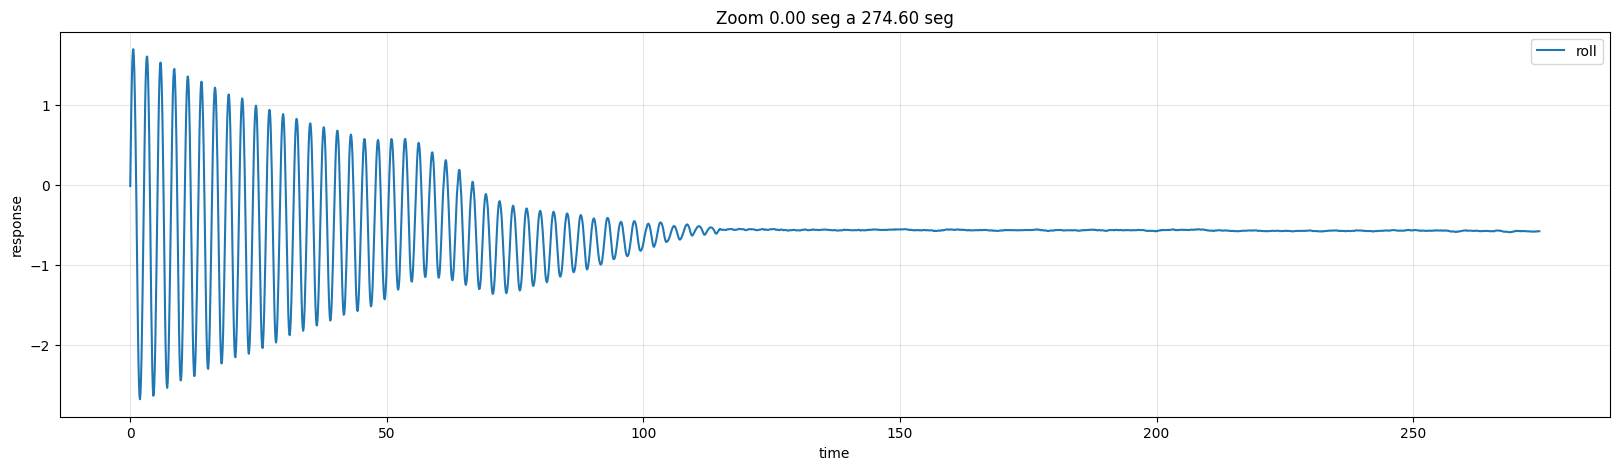

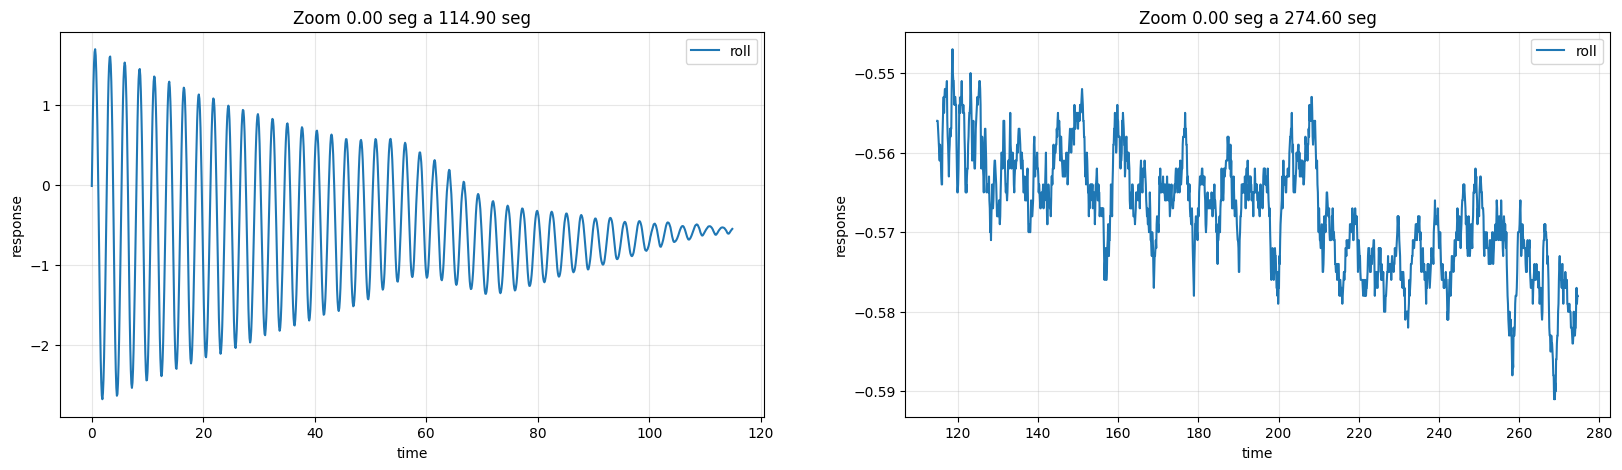

In [30]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plotViews(df, limits=(0, 1))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static, limits=(0, 1))

# SALVANDO DADOS

In [31]:
df = df.rename(columns={col: 'target_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,target_yaw,target_wz,target_wy,target_tmp,target_e,target_roll,target_wx,target_ay,target_pitch,target_ax,target_az,static
0,0.0,5.416,-29.72311,0.69735,50.7,3.168,-0.012,5.73980,10.291363,5.690,0.492372,-0.087240,False
1,0.1,5.365,-27.21794,0.31555,50.7,6.120,0.479,4.63504,10.162828,8.535,0.434974,-0.171234,False
2,0.2,5.307,-23.70273,0.66688,50.8,8.748,0.915,3.65632,10.044334,11.083,0.352696,-0.354030,False
3,0.3,5.247,-17.93960,-0.15860,50.7,10.800,1.271,3.30784,9.532240,13.199,0.231192,0.168684,False
4,0.4,5.199,-12.63890,0.35007,50.9,12.276,1.524,1.79823,9.415345,14.754,0.283520,-0.115483,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2743,274.2,7.649,-0.29984,0.06138,54.5,0.396,-0.579,0.25000,9.770395,3.359,0.599961,-0.092712,True
2744,274.3,7.649,-0.17035,-0.34457,54.2,0.396,-0.577,0.37820,9.766962,3.359,0.571483,-0.130066,True
2745,274.4,7.651,-0.30838,0.31484,54.5,0.396,-0.579,-0.06058,9.765207,3.359,0.585251,-0.111364,True
2746,274.5,7.651,0.32828,-0.00989,54.5,0.396,-0.578,0.17020,9.774916,3.359,0.570021,-0.102156,True


In [32]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)